# CME Futures: Label Engineering

Every model in this case study is trained to predict the label defined here, so an error
in it is silent where it is made and reaches every metric and every backtest after it.
This notebook fixes the execution convention, proves each labelled row has a complete
forward window inside one product, measures how much independent information those rows
carry, establishes the floor a feature has to clear, and writes the files stage 03 reads.

## Learning objectives

- Choose between a futures dataset's two price series, and say which quantity each one
  answers for
- Express a forward return as an execution convention, then assert - rather than describe -
  that every labelled window is complete and gap-free inside one product
- Seal a diagnostic on the label's endpoint rather than on its observation date
- Price the overlap in a multi-session label, both as decay and as an effective row count
- Establish the floor a feature has to clear, under a standard error that prices in that
  overlap

## Book reference, prerequisites and artifacts

Chapter 7, Section 7.2. Reads the roll-adjusted daily settlement panel through
`load_cme_futures()`, whose coverage
[`01_feasibility_analysis`](01_feasibility_analysis.ipynb) establishes, and
`config/setup.yaml`, which declares the universe, the label set, the horizons and the
holdout boundary. Writes `labels/fwd_ret_5d.parquet` and `labels/fwd_ret_21d.parquet`,
each with a `.digest.json` sidecar beside it. `03_financial_features.py` reads whichever
label is `labels.primary`.

In [1]:
"""CME Futures: Label Engineering."""

import math
import warnings
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.label_diagnostics import effective_sample_size, panel_autocorrelation
from data import load_cme_futures
from utils.artifact_specs import resolve_label_horizon
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

warnings.filterwarnings("ignore")

CASE_STUDY_ID = "cme_futures"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
LABELS_DIR = CASE_DIR / "labels"

Both parameters are unset by default, and both are read below. `START_DATE` trims the
history to a later start; `MAX_PRODUCTS` keeps only the first products in alphabetical
order. Either one shortens a run at the cost of a thinner panel: the rank correlation in
Section G and the cross-sectional dispersion in Section E both need a wide cross-section
on each session to mean anything.

In [2]:
MAX_PRODUCTS = None
START_DATE = None

## Configuration

Everything that defines a label is declared in `config/setup.yaml` and bound here. A
horizon or a boundary typed into a cell is a second copy of a value the rest of the
pipeline reads from the file, and the two drift apart the first time either is edited.

`resolve_label_horizon` prefers an explicit `labels.horizons` entry and falls back to the
cross-validation buffer. The two fields are separate, because the gap that keeps folds
independent need not equal the horizon an outcome resolves over; here they coincide, and
both are declared in trading sessions.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

PRIMARY_LABEL = setup["labels"]["primary"]
LABEL_NAMES = [PRIMARY_LABEL, *setup["labels"].get("variants", [])]
VARIANT_LABEL = LABEL_NAMES[1]
HORIZONS = {
    name: int(resolve_label_horizon(CASE_STUDY_ID, name, setup).rstrip("Dd"))
    for name in LABEL_NAMES
}
PRIMARY_HORIZON = HORIZONS[PRIMARY_LABEL]
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])
GROUPS = setup["universe"]["product_groups"]
SECTORS = {product: sector for sector, ps in GROUPS.items() for product in ps}

print(f"Labels: {LABEL_NAMES}, primary {PRIMARY_LABEL}, horizons {HORIZONS} sessions")
print(f"Holdout opens {HOLDOUT_START}, and seals the label endpoint")

Labels: ['fwd_ret_5d', 'fwd_ret_21d'], primary fwd_ret_5d, horizons {'fwd_ret_5d': 5, 'fwd_ret_21d': 21} sessions
Holdout opens 2024-01-01, and seals the label endpoint


## A. The learning task

The hypothesis is cross-sectional and it is about the shape of each futures curve. A
product whose front contract trades above the next one - backwardation - is one the market
is paying to hold, and the claim is that such products out-earn those in contango over the
following week, ranked against each other rather than judged in isolation. The label is
therefore a forward price return on the front contract, and the strategy that consumes it
is long-short across the thirty products.

The decision cadence comes from `setup.yaml`: a Friday settlement is observed, and the
resulting position is entered at Monday's open. That fixes the primary horizon at one
trading week. The monthly variant asks whether the same curve signal still pays when the
book turns over a fifth as often - a question about cost and turnover rather than a second
hypothesis. Labels are sampled every session rather than only on Fridays: that buys five
times the rows at the price of overlap, and Section F measures what they are worth.

## B. Preparation before the label

**Two price series, two jobs, and picking the wrong one is the mistake this dataset
invites.** Every row carries a raw traded settlement (`raw_close`) and a roll-continuous,
ratio-adjusted level (`adj_close`). A forward return has to ride the adjusted series:
ratio back-adjustment rescales the pre-roll history so that rolling from one contract to
the next does not register as a price move, and a return taken across a roll date on the
raw series would report the front-to-deferred basis gap as profit. A contemporaneous
term-structure quantity - the carry signal in Section G, and every curve feature in stage
03 - reads `raw_close` instead, because differencing two *adjusted* tenors measures their
accumulated roll history rather than today's curve. Chapter 2's
[`06_futures_continuous`](../../02_financial_data_universe/06_futures_continuous.ipynb)
constructs the adjusted series.

The loader returns three tenors per product: `position` 0 is the front contract, 1 and 2
the next two. Only the front contract is labelled, because it is the one the strategy
trades, and it is separated here rather than later: `position` is part of the entity key,
so keeping one position removes whole entities rather than rows from inside one. No
eligibility filter runs before the shift, and that ordering matters: once rows are dropped
from inside a series, a shift counts survivors, the horizon stops being measured in
trading sessions, and the window silently spans whatever was removed. The universe is the
fixed thirty-product list `setup.yaml` declares.

In [4]:
bars = load_cme_futures().rename({"session_date": "timestamp", "tenor": "position"})
if START_DATE is not None:
    bars = bars.filter(pl.col("timestamp") >= date.fromisoformat(START_DATE))
if MAX_PRODUCTS is not None:
    keep = sorted(bars["product"].unique().to_list())[:MAX_PRODUCTS]
    bars = bars.filter(pl.col("product").is_in(keep))
bars = bars.sort(["product", "position", "timestamp"])
front = bars.filter(pl.col("position") == 0)

# Recorded as every label's `inputs`: a re-run against a refreshed download is
# otherwise indistinguishable from this one.
MARKET_DATA_DIGEST = value_digest(front, ["product", "position", "timestamp", "adj_close"])

print(f"{front['product'].n_unique()} products, {front.height:,} front-contract sessions")
print(f"Sessions {front['timestamp'].min()} to {front['timestamp'].max()}")
print(f"market_data digest: {MARKET_DATA_DIGEST}")

30 products, 113,506 front-contract sessions
Sessions 2011-01-03 to 2025-12-31
market_data digest: daf59aba86a6f11e


## C. Label construction

One execution convention, written once and applied at both horizons:

$$r^{(h)}_{p,t} = \frac{A_{p,t+h}}{A_{p,t}} - 1$$

where $A$ is the ratio-adjusted settlement of product $p$'s front contract and $t+h$
counts $h$ **trading sessions for that product**: Chapter 7.2's close-to-close convention.
It is not the convention the backtest fills at - `setup.yaml` places execution at Monday's
open - and that difference is a real gap, left to `15_costs`, which sweeps commission and
spread rather than the return definition.

The denominator is guarded rather than clipped. A settlement can be non-positive: CL's
second tenor settled below zero on 2020-04-20, and dividing by a clipped floor would
manufacture an enormous return instead of admitting the quantity is undefined. The
front contract never goes non-positive in this panel, and Section D's reconciliation is
what shows that rather than asserting it.

Two bookkeeping columns are numbered here, on the complete session series, because both
mean something only before a row is dropped: `from_end` counts back from each product's
last session for Section D's boundary profile, and `session` numbers its sessions forward
so Section F's overlap statistics keep counting trading sessions once the null tail and
the holdout are filtered out. Neither reaches a label parquet, which selects four columns.

In [5]:
def forward_return(df: pl.DataFrame, horizon: int, name: str) -> pl.DataFrame:
    """Close-to-close return over `horizon` sessions, null where the window spans a hole."""
    base = pl.when(pl.col("adj_close") > 0).then(pl.col("adj_close"))
    holes_ahead = pl.col("_holes").shift(-horizon).over("product") - pl.col("_holes")
    return df.with_columns(
        pl.when(holes_ahead == 0)
        .then(pl.col("adj_close").shift(-horizon).over("product") / base - 1)
        .otherwise(None)
        .alias(name)
    )


# A session-to-session spacing above a long weekend plus an exchange holiday is a hole in
# the product's series, not a calendar effect. `_holes` counts them cumulatively, so a
# window spanning one is found by differencing the count at its two ends.
MAX_SESSION_GAP_DAYS = 5
spacing = (pl.col("timestamp") - pl.col("timestamp").shift(1).over("product")).dt.total_days()

labels_df = front.with_columns(
    (pl.len().over("product") - 1 - pl.int_range(pl.len()).over("product")).alias("from_end"),
    pl.int_range(pl.len()).over("product").alias("session"),
    (spacing > MAX_SESSION_GAP_DAYS).fill_null(False).cum_sum().over("product").alias("_holes"),
)
for label_name, horizon in HORIZONS.items():
    labels_df = forward_return(labels_df, horizon, label_name)
labels_df = labels_df.with_columns(
    pl.col("timestamp").shift(-PRIMARY_HORIZON).over("product").alias("_label_end")
)

print(f"Constructed {', '.join(LABEL_NAMES)}")
gaps = labels_df.group_by("product").agg(pl.col("_holes").max()).filter(pl.col("_holes") > 0)
print(f"{gaps['_holes'].sum()} holes above {MAX_SESSION_GAP_DAYS} days, in {gaps.height} products")

Constructed fwd_ret_5d, fwd_ret_21d
3 holes above 5 days, in 3 products


## D. Window validity

A shift always returns something; the question is whether what it returns is the quantity
the label claims. Each property below fails silently and leaves plausible numbers behind,
so each is asserted rather than described.

The second assertion is a full reconciliation rather than a bound. Every row carrying no
label is attributed to exactly one cause - the tail of its product's series, a hole inside
the forward window, or a non-positive settlement at the anchor - and the four counts have
to sum to the height of the frame. A label crossing a product boundary, or a short label
masked by a longer one's null set, would break that identity.

The third assertion bounds the calendar span a window may cover, which is what makes the
hole rule falsifiable rather than a definition: $h$ trading sessions span about $7h/5$
calendar days on a five-session week, plus a week for exchange holidays. The panel's only
hole is an outage in the three livestock products in February 2012, and without the hole
rule the monthly label there spans more days than any holiday pattern can account for.

In [6]:
for label_name, horizon in HORIZONS.items():
    checked = labels_df.with_columns(
        (pl.col("timestamp").shift(-horizon).over("product") - pl.col("timestamp"))
        .dt.total_days()
        .alias("_span")
    )
    tail = pl.col("from_end") < horizon
    holed = pl.col("_holes").shift(-horizon).over("product") != pl.col("_holes")
    unpriced = ~tail & ~holed & (pl.col("adj_close") <= 0)
    causes = {"tail": tail, "hole in window": ~tail & holed, "no anchor price": unpriced}
    # 1. An incomplete forward window is null, never a value.
    assert checked.filter(tail)[label_name].null_count() == checked.filter(tail).height

    # 2. Labelled rows plus the three causes account for every row, each cause once.
    counts = {cause: checked.filter(cond).height for cause, cond in causes.items()}
    labelled = checked.drop_nulls(label_name)
    assert labelled.height + sum(counts.values()) == checked.height, (label_name, counts)

    # 3. No labelled window spans more calendar days than holidays alone can explain.
    tolerance = math.ceil(horizon * 7 / 5) + 7
    assert labelled.filter(pl.col("_span") > tolerance).height == 0, label_name

    # 4. No discrete label is derived from a null return - vacuous by dtype here, since
    #    this notebook writes continuous labels only.
    assert labels_df.schema[label_name] == pl.Float64, label_name

    unlabelled = ", ".join(f"{n:,} {cause}" for cause, n in counts.items())
    print(
        f"{label_name}: {labelled.height:,} labelled, spans up to {labelled['_span'].max()}d "
        f"against a {tolerance}d tolerance; unlabelled {unlabelled}"
    )

fwd_ret_5d: 113,341 labelled, spans up to 12d against a 14d tolerance; unlabelled 150 tail, 15 hole in window, 0 no anchor price
fwd_ret_21d: 112,813 labelled, spans up to 35d against a 37d tolerance; unlabelled 630 tail, 63 hole in window, 0 no anchor price


Position zero below is each product's last session. The non-null rate has to fall to zero
over exactly the last `horizon` positions and sit flat beyond them. A scalar count of
valid rows shows neither failure this catches: a tail fabricated instead of nulled, or a
short label masked by a longer one's null set. The figure reads only the null structure
and never a value, so it is not sealed - it describes the shape of the artifact.

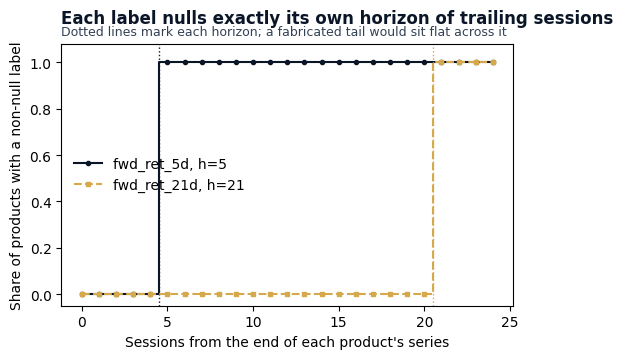

In [7]:
profile = (
    labels_df.filter(pl.col("from_end") <= max(HORIZONS.values()) + 3)
    .group_by("from_end")
    .agg([pl.col(name).is_not_null().mean().alias(name) for name in LABEL_NAMES])
    .sort("from_end")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name, colour, fmt in zip(
    LABEL_NAMES, (COLORS["blue"], COLORS["amber"]), ("o-", "s--"), strict=True
):
    tag = f"{name}, h={HORIZONS[name]}"
    ax.plot(profile["from_end"], profile[name], fmt, ds="steps-mid", ms=3, c=colour, label=tag)
    ax.axvline(HORIZONS[name] - 0.5, color=colour, linestyle=":", lw=1)
ax.set_xlabel("Sessions from the end of each product's series")
ax.set_ylabel("Share of products with a non-null label")
ax.set_ylim(-0.05, 1.08)
add_message_title(
    ax,
    "Each label nulls exactly its own horizon of trailing sessions",
    subtitle="Dotted lines mark each horizon; a fabricated tail would sit flat across it",
)
ax.legend(loc="center left", frameon=False)
show_with_alt(fig, "Non-null label rate by position from the end of each product's series.")

## E. Distribution and base rate

What scale is the label, and does it mean the same thing across products and across
regimes? Everything from here through Section G is computed on the development window
only, sealed on the label's **endpoint** rather than its observation date: a row observed
shortly before the holdout still resolves inside it, so a filter on the observation date
looks sealed and is not. The label files keep every row, because the seal governs what
this notebook looks at rather than what it writes.

In [8]:
dev = {
    name: labels_df.with_columns(
        pl.col("timestamp").shift(-horizon).over("product").alias("_label_end")
    )
    .filter(pl.col("_label_end") < HOLDOUT_START)
    .drop_nulls(name)
    .with_columns(pl.col("product").replace_strict(SECTORS).alias("sector"))
    for name, horizon in HORIZONS.items()
}
for label_name, frame in dev.items():
    print(f"{label_name}: {frame.height:,} development rows through {frame['timestamp'].max()}")

fwd_ret_5d: 97,951 development rows through 2023-12-21
fwd_ret_21d: 97,423 development rows through 2023-11-29


Both labels go on one axis with identical bins and a logarithmic count axis. The claim the
figure has to support is about shape rather than width - two dispersion scalars would
carry the width - and the shape here is that the monthly label's extra mass goes into the
tails rather than spreading the body evenly. The axis is symmetric and narrower than
either label's range, so rows outside it are counted below rather than drawn.

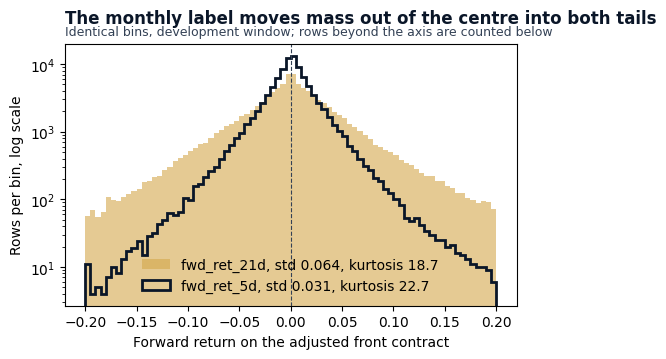

fwd_ret_5d: std 0.03138, kurtosis 22.72, 73 left and 68 right of the axis
fwd_ret_21d: std 0.06405, kurtosis 18.67, 623 left and 782 right of the axis
width ratio 2.04 against 2.05 under square-root-of-horizon scaling


In [9]:
bins = np.linspace(-0.20, 0.20, 81)
styles = {
    VARIANT_LABEL: dict(color=COLORS["amber"], alpha=0.6, zorder=1),
    PRIMARY_LABEL: dict(color=COLORS["blue"], histtype="step", lw=2, zorder=2),
}
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name in (VARIANT_LABEL, PRIMARY_LABEL):
    series = dev[name][name]
    tag = f"{name}, std {series.std():.3f}, kurtosis {series.kurtosis():.1f}"
    ax.hist(series.to_numpy(), bins=bins, label=tag, **styles[name])
ax.axvline(0, color=COLORS["neutral"], linestyle="--", lw=0.8)
ax.set_yscale("log")
ax.set_xlabel("Forward return on the adjusted front contract")
ax.set_ylabel("Rows per bin, log scale")
add_message_title(
    ax,
    "The monthly label moves mass out of the centre into both tails",
    subtitle="Identical bins, development window; rows beyond the axis are counted below",
)
ax.legend(loc="lower center", frameon=False)
show_with_alt(fig, "Histograms of both labels on identical bins and a log count axis.")

std = {name: dev[name][name].std() for name in LABEL_NAMES}
root_h = math.sqrt(HORIZONS[VARIANT_LABEL] / PRIMARY_HORIZON)
for name in LABEL_NAMES:
    frame, column = dev[name], pl.col(name)
    out = frame.filter(column < bins[0]).height, frame.filter(column > bins[-1]).height
    print(
        f"{name}: std {std[name]:.5f}, kurtosis {frame[name].kurtosis():.2f}, "
        f"{out[0]:,} left and {out[1]:,} right of the axis"
    )
ratio = std[VARIANT_LABEL] / std[PRIMARY_LABEL]
print(f"width ratio {ratio:.2f} against {root_h:.2f} under square-root-of-horizon scaling")

Chapter 7.2 asks for the base rate to be tracked through time. For a continuous label
ranked across a cross-section, the quantity that has to be stable is the spread the model
ranks within: where it is not, the same rank correlation buys a different amount of
return. The spread is taken across products on each session first and only then averaged
over the year. Pooling every product-session in a year into one standard deviation instead
measures something else: it adds the movement of the panel's own mean from session to
session to the spread across products on a session, and a ranking model is scored on the
second alone.

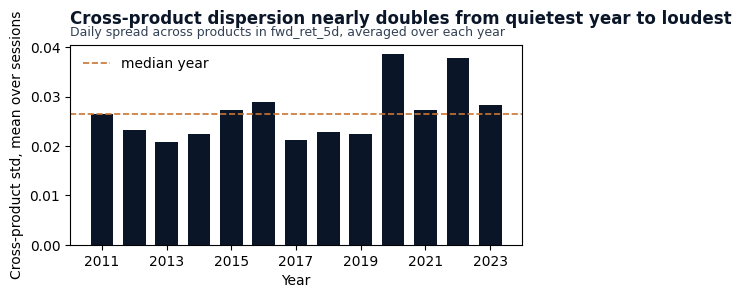

dispersion peaks at 3.9% in 2020 against 2.1% in 2013, a ratio of 1.86; median year 2.7%


In [10]:
annual = (
    dev[PRIMARY_LABEL]
    .group_by("timestamp")
    .agg(pl.col(PRIMARY_LABEL).std().alias("dispersion"))
    .with_columns(pl.col("timestamp").dt.year().alias("year"))
    .group_by("year")
    .agg(pl.col("dispersion").mean())
    .sort("year")
)
peak, low = (annual.sort("dispersion", descending=d).row(0, named=True) for d in (True, False))
median_dispersion = annual["dispersion"].median()

fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
ax.bar(annual["year"], annual["dispersion"], color=COLORS["blue"], width=0.7)
ax.axhline(median_dispersion, color=COLORS["copper"], linestyle="--", lw=1.2, label="median year")
ax.set_xticks(annual["year"].to_list()[::2])
ax.set_xlabel("Year")
ax.set_ylabel("Cross-product std, mean over sessions")
add_message_title(
    ax,
    "Cross-product dispersion nearly doubles from quietest year to loudest",
    subtitle=f"Daily spread across products in {PRIMARY_LABEL}, averaged over each year",
)
ax.legend(loc="upper left", frameon=False)
show_with_alt(fig, "Annual mean of the daily cross-product dispersion of the primary label.")

print(
    f"dispersion peaks at {peak['dispersion']:.1%} in {peak['year']:.0f} against "
    f"{low['dispersion']:.1%} in {low['year']:.0f}, a ratio of "
    f"{peak['dispersion'] / low['dispersion']:.2f}; median year {median_dispersion:.1%}"
)

The same spread taken within each sector is what argues against a single pooled scale.
Energy and treasuries are the same instrument class and the same label, and the widths
they produce are not comparable, so a model fitted on a pooled target spends most of its
capacity on the loud sectors. That is the argument for the cross-sectional rank the
strategy uses and for the per-sector normalization stage 03 applies.

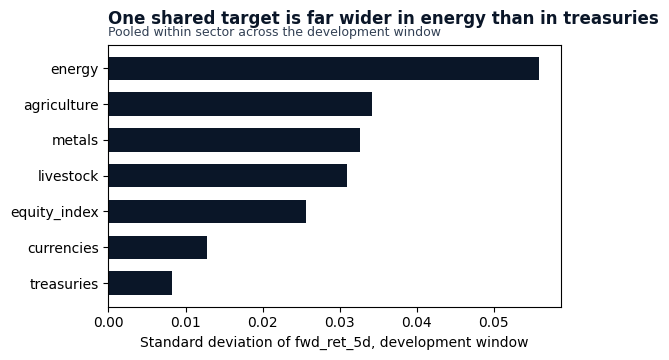

shape: (7, 3)
┌──────────────┬──────────┬───────┐
│ sector       ┆ std      ┆ rows  │
│ ---          ┆ ---      ┆ ---   │
│ str          ┆ f64      ┆ u32   │
╞══════════════╪══════════╪═══════╡
│ treasuries   ┆ 0.008212 ┆ 13361 │
│ currencies   ┆ 0.012796 ┆ 20022 │
│ equity_index ┆ 0.02566  ┆ 11703 │
│ livestock    ┆ 0.030923 ┆ 9758  │
│ metals       ┆ 0.032697 ┆ 13385 │
│ agriculture  ┆ 0.034176 ┆ 16334 │
│ energy       ┆ 0.055865 ┆ 13388 │
└──────────────┴──────────┴───────┘
widest sector is 6.8x the narrowest on the same label


In [11]:
sector_std = (
    dev[PRIMARY_LABEL]
    .group_by("sector")
    .agg(pl.col(PRIMARY_LABEL).std().alias("std"), pl.len().alias("rows"))
    .sort("std")
)
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.barh(sector_std["sector"], sector_std["std"], color=COLORS["blue"], height=0.65)
ax.set_xlabel(f"Standard deviation of {PRIMARY_LABEL}, development window")
add_message_title(
    ax,
    "One shared target is far wider in energy than in treasuries",
    subtitle="Pooled within sector across the development window",
)
show_with_alt(fig, "Standard deviation of the primary label by product sector.")

spread = sector_std["std"].max() / sector_std["std"].min()
print(f"{sector_std}\nwidest sector is {spread:.1f}x the narrowest on the same label")

On the development window the weekly label has a standard deviation of 0.03138 and the
monthly label 0.06405, a ratio of 2.04 against the 2.05 that square-root-of-horizon
scaling implies. Neither the spread across products nor the spread within one sector is
stable: cross-product dispersion peaks at 3.9% in 2020 against a 2.7% median year, and
pooled within sector the weekly label runs from 0.008212 in treasuries to 0.055865 in
energy, so the widest sector is 6.8x the narrowest on one shared target.

## F. Overlap and effective sample size

Sampling a multi-session label at every session makes consecutive rows share most of their
forward window, so the row count overstates the evidence. Two measurements answer that in
different units: how fast the overlap decays, and what the rows are worth once it is
priced in. `effective_sample_size` applies Chapter 7.2's average-uniqueness weighting per
product, because concurrency is a property of one product's own overlapping windows.

Both are counted on `session`, the grid the label was built on, rather than on position
among the rows that survive to the development frame. Closing over the February 2012
outage would pair windows that share nothing and report the overlap as larger than it is.

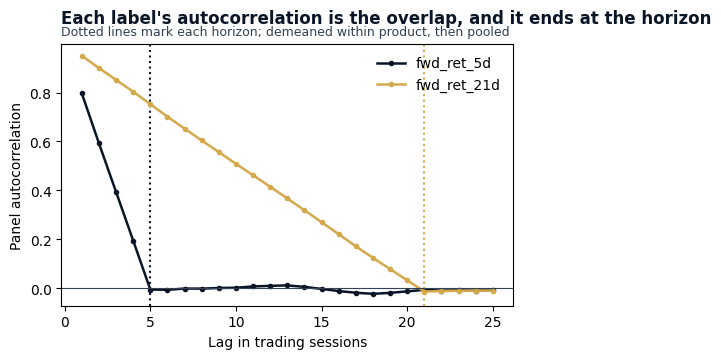

fwd_ret_5d: N=97,951, N_eff=19,617, ratio 0.2003 against 0.2000 for windows overlapping this fully; autocorrelation 0.797 at lag one, -0.005 at its horizon


fwd_ret_21d: N=97,423, N_eff=4,671, ratio 0.0479 against 0.0476 for windows overlapping this fully; autocorrelation 0.950 at lag one, -0.013 at its horizon


In [12]:
max_lag = HORIZONS[VARIANT_LABEL] + 4
acf = {
    name: panel_autocorrelation(
        dev[name], name, max_lag=max_lag, bar_col="session", entity_col="product"
    )
    for name in LABEL_NAMES
}

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
lags = np.arange(1, max_lag + 1)
for name, colour in zip(LABEL_NAMES, (COLORS["blue"], COLORS["amber"]), strict=True):
    ax.plot(lags, acf[name], "o-", ms=3, c=colour, lw=1.8, label=name)
    ax.axvline(HORIZONS[name], color=colour, linestyle=":", lw=1.5)
ax.axhline(0, color=COLORS["neutral"], lw=0.8)
ax.set_xlabel("Lag in trading sessions")
ax.set_ylabel("Panel autocorrelation")
add_message_title(
    ax,
    "Each label's autocorrelation is the overlap, and it ends at the horizon",
    subtitle="Dotted lines mark each horizon; demeaned within product, then pooled",
)
ax.legend(loc="upper right", frameon=False)
show_with_alt(fig, "Panel autocorrelation of both labels against lag in trading sessions.")

# A horizon-h label consumes the h returns realised over its window, and its neighbour one
# session later shares h-1 of them, so average uniqueness converges to 1/h.
for label_name, horizon in HORIZONS.items():
    n_rows, n_eff = effective_sample_size(
        dev[label_name], horizon=horizon, bar_col="session", entity_col="product"
    )
    print(
        f"{label_name}: N={n_rows:,}, N_eff={n_eff:,.0f}, ratio {n_eff / n_rows:.4f} against "
        f"{1 / horizon:.4f} for windows overlapping this fully; autocorrelation "
        f"{acf[label_name][0]:.3f} at lag one, {acf[label_name][horizon - 1]:.3f} at its horizon"
    )

The weekly label's 97,951 development rows carry 19,617 effective observations, a ratio of
0.2003 against the 0.2000 a fully overlapped five-session window implies; the monthly
label's 97,423 rows carry 4,671, a ratio of 0.0479 against 0.0476. Both sit just above the
reference value because the February 2012 outage ends an overlap early. Autocorrelation
falls from 0.797 at lag one to -0.005 at lag five for the weekly label, and from 0.950 to
-0.013 at lag twenty-one for the monthly one. The purge gap a fold needs is set by the
forward window itself, not by these counts.

## G. Baseline floor

One signal against the primary label on the sealed development window, with no feature
engineering: the raw carry the hypothesis names, annualised as
$12 \times (F_1 - F_2) / F_1$ from the two nearest **raw** settlements, which is what
`03_financial_features` recomputes under the name `carry_pct`. Measuring the floor before
building features is what makes a later improvement meaningful.

The information coefficient is the cross-sectional rank correlation on each session,
averaged over sessions, which is the quantity a ranking model is scored on; pooling every
product-session instead mixes a cross-sectional claim with a time-series one. The
library call returns its series ordered by time, which the standard error depends on. The
minimum cross-section is half the median rather than a bare count, so it means the same
thing on a universe of another size. The standard error is HAC-adjusted, because the IC
series inherits the label's overlap and a naive statistic would treat five consecutive
sessions of one week's return as five pieces of evidence.

In [13]:
second = bars.filter(pl.col("position") == 1).select(
    ["product", "timestamp", pl.col("raw_close").alias("_next_close")]
)
baseline = (
    dev[PRIMARY_LABEL]
    .join(second, on=["product", "timestamp"], how="inner")
    .with_columns(
        pl.when(pl.col("raw_close") > 0)
        .then(12 * (pl.col("raw_close") - pl.col("_next_close")) / pl.col("raw_close"))
        .alias("carry_pct")
    )
    .drop_nulls("carry_pct")
)
min_obs = int(baseline.group_by("timestamp").len()["len"].median() // 2)

ic = cross_sectional_ic_series(
    baseline,
    baseline,
    pred_col="carry_pct",
    ret_col=PRIMARY_LABEL,
    date_col="timestamp",
    entity_col="product",
    min_obs=min_obs,
).sort("timestamp")  # HAC autocovariances are meaningless over a permutation of time
stats = compute_ic_hac_stats(ic, ic_col="ic", label_horizon=PRIMARY_HORIZON)

print(
    f"Baseline: annualised front-to-next carry against {PRIMARY_LABEL}, "
    f"{baseline.height:,} rows, minimum cross-section {min_obs} products"
)
print(f"  sessions scored {ic.height:,}, mean IC {stats['mean_ic']:.4f}")
print(
    f"  HAC t {stats['t_stat']:.2f} on {stats['effective_lags']} Bartlett lags, "
    f"naive t {stats['naive_t_stat']:.2f}, p {stats['p_value']:.3g}"
)

Baseline: annualised front-to-next carry against fwd_ret_5d, 96,090 rows, minimum cross-section 14 products
  sessions scored 3,352, mean IC 0.0069
  HAC t 0.87 on 8 Bartlett lags, naive t 1.61, p 0.387


Raw carry earns a mean information coefficient of 0.0069 against the weekly label over
3,352 scored sessions on a cross-section of at least 14 products, positive as the
backwardation hypothesis implies. Under the naive standard error that is a t-statistic of
1.61; the Newey-West rule picks 8 lags here, above the four the horizon alone requires,
and the HAC statistic is 0.87 with a p-value of 0.387. The floor a feature has to clear is
a mean IC of 0.0069 that the data cannot separate from zero.

## H. Artifacts and the audit record

Each label is written with a digest sidecar beside it, recording the content digest of the
values written, the row count, the key columns, the notebook that wrote it and the digest
of the price data it was built from. That last field is what ties a label to its data
vintage. `position` stays in the key even though every row is the front contract, because
it is part of the identity stage 03 joins on.

The folds that train models are derived per label by `case_studies/utils/cv_window.py`
from `config/setup.yaml` and the timeline of the label parquet written here, so which rows
land in these files is what sets where the fold boundaries fall.

In [14]:
for label_name in LABEL_NAMES:
    keys = ["timestamp", "product", "position"]
    record = write_artifact(
        labels_df.select([*keys, label_name]).drop_nulls(),
        LABELS_DIR / f"{label_name}.parquet",
        keys=keys,
        written_by="02_labels",
        inputs={"market_data": MARKET_DATA_DIGEST},
    )
    print(f"{label_name}.parquet: {record['n_rows']:,} rows, digest {record['digest']}")

fwd_ret_5d.parquet: 113,341 rows, digest 51fbf4ac683f7696
fwd_ret_21d.parquet: 112,813 rows, digest e8b53247d2903eaa


The record Chapter 7.2 requires to close a label definition, one row per label, built from
the values computed above rather than written by hand.

In [15]:
readers = {PRIMARY_LABEL: "03_financial_features.py, as `labels.primary`"}
print("\nLabel audit record")
for label_name, horizon in HORIZONS.items():
    frame = dev[label_name]
    print(
        f"\n{label_name}\n  anchor       ratio-adjusted front-contract settlement at t"
        f"\n  horizon      {horizon} trading sessions on the product's own calendar"
        f"\n  resolution   fixed at t+h; daily settlements need no intraday tie-break"
        f"\n  overlap      {horizon - 1} sessions shared by consecutive rows"
        f"\n  base rate    mean {frame[label_name].mean():+.5f}, std {frame[label_name].std():.5f}"
        f"\n  consumed by  {readers.get(label_name, 'the model stages, as a variant')}"
    )


Label audit record

fwd_ret_5d
  anchor       ratio-adjusted front-contract settlement at t
  horizon      5 trading sessions on the product's own calendar
  resolution   fixed at t+h; daily settlements need no intraday tie-break
  overlap      4 sessions shared by consecutive rows
  base rate    mean +0.00031, std 0.03138
  consumed by  03_financial_features.py, as `labels.primary`

fwd_ret_21d
  anchor       ratio-adjusted front-contract settlement at t
  horizon      21 trading sessions on the product's own calendar
  resolution   fixed at t+h; daily settlements need no intraday tie-break
  overlap      20 sessions shared by consecutive rows
  base rate    mean +0.00118, std 0.06405
  consumed by  the model stages, as a variant


## Key takeaways

1. **On a futures panel, decide which price series answers which question before writing
   anything.** A return has to ride the roll-adjusted series or a roll registers as
   profit; a curve quantity has to ride the raw one or it measures accumulated roll
   history. The two look interchangeable and are not.
2. **Assert the window and reconcile every unlabelled row to one cause.** An incomplete
   window, a hole in a product's series and a label crossing a product boundary all fail
   without raising, and a reconciliation that has to balance catches what a row count
   passed over does not.
3. **Seal a diagnostic on the label's endpoint.** A row observed before the holdout whose
   outcome resolves inside it is a holdout row, so the usable boundary is the boundary
   minus the horizon, counted on each product's own sessions.
4. **A row count overstates the evidence when forward windows overlap.** The effective
   count says by how much, and it does not set the purge gap - the forward window does.
5. **Check that one target is the same size everywhere before pooling it.** Sector
   dispersion here spans a factor of seven, which is the argument for ranking
   cross-sectionally rather than regressing on a pooled scale.

**Known limitations.** Close-to-close is not the Monday-open execution the backtest fills
at, and nothing here measures that gap. The universe is a fixed thirty-product list rather
than a liquidity screen applied point in time. The hole rule is a calendar-spacing test on
each product's own series, so it finds an outage of days and not a single absent session.
The baseline is one signal, on the nearest two tenors only.

**Next**: `03_financial_features.py` builds the carry, momentum, seasonal and composite
features and evaluates them against these labels.